In [1]:
import re
import time
import numpy as np
import pandas as pd
import scipy.optimize
import matplotlib.pyplot as plt
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.nquality import QualityBuilder
from pipedream_solver.simulation import Simulation
from pipedream_solver.nutils import bounded_newton_raphson
import pipedream_solver.ngeometry
import swmmio
import swmmtoolbox

In [2]:
superjunctions = pd.read_csv('../data/wds_paper_examples/net2/net2_superjunctions.csv', index_col=0)
superlinks = pd.read_csv('../data/wds_paper_examples/net2/net2_superlinks.csv', index_col=0)
orifices = pd.read_csv('../data/wds_paper_examples/net2/net2_orifices.csv', index_col=0)
multipliers = pd.read_csv('../data/wds_paper_examples/net2/net2_multipliers.csv', index_col=0)

In [3]:
H_epanet = pd.read_csv('../data/wds_paper_examples/net2/net2_heads_epanet.csv', index_col=0)
Q_epanet = pd.read_csv('../data/wds_paper_examples/net2/net2_flows_epanet.csv', index_col=0)

In [4]:
model = SuperLink(superlinks, superjunctions, orifices=orifices, internal_links=1)

In [5]:
Q_in = pd.concat([-model.superjunctions['demand_pattern'].map(multipliers.loc[i]).fillna(0.) 
                * model.superjunctions['base_demand'] for i in multipliers.index], axis=1).T
Q_in.index = Q_in.index.values * 3600

In [6]:
# Use EPANET floor indexing
for i in range(len(Q_in) - 1):
    ix = Q_in.index[i]
    ix_next = Q_in.index[i+1] - 1
    Q_in.loc[ix_next] = Q_in.loc[ix]

In [7]:
num_tanks = 1
num_pumps = 0

In [8]:
u_o = np.ones(num_tanks)
u_p = np.ones(num_pumps)

is_tank = model.superjunctions['tank'].values
is_tank_fake_node = model.superjunctions['tank_fake_node'].values
tank_min = model.superjunctions['tank_min'].values
tank_max = model.superjunctions['tank_max'].values 
is_criteria = [False, False, True, False, False, False, False, False, False, False, False, False]

In [9]:
model.spinup(n_steps=10, dt=60, Q_in=Q_in.loc[0].values, u_o=u_o)

In [10]:
dt = 1800

with Simulation(model, Q_in=Q_in, t_end=H_epanet.index[-1], interpolation_method='nearest') as simulation:
    # While simulation time has not expired...
    while simulation.t <= simulation.t_end:
        # Step model forward in time
        simulation.step(dt=dt, num_iter=40, u_o=u_o, head_tol=0.0001)
        u_o = ((model.H_j[is_tank_fake_node] > tank_min[is_tank_fake_node] + 0.1)
               & (model.H_j[is_tank_fake_node] < tank_max[is_tank_fake_node] - 0.1)).astype(np.float64)
        # Record internal depth and flow states
        simulation.record_state()
        # Print progress bar
        simulation.print_progress()

[==================================================] 100.0% [0.35 s]

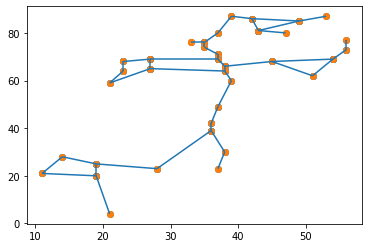

In [11]:
_ = model.plot_network_2d()

# EPANET

<AxesSubplot:>

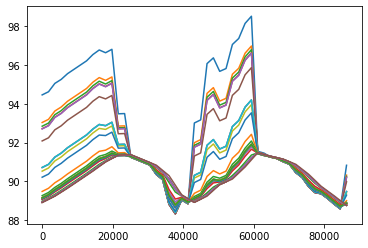

In [12]:
H_epanet.plot(legend=False)

<AxesSubplot:>

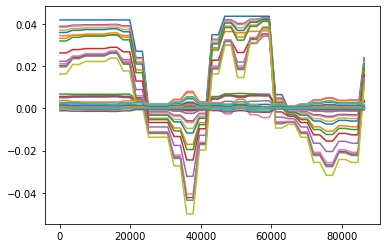

In [13]:
Q_epanet.plot(legend=False)

# PipeDream

<AxesSubplot:>

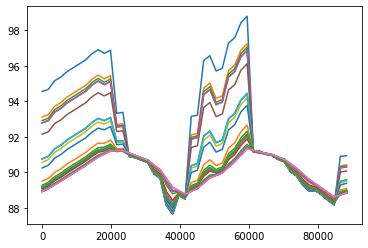

In [14]:
simulation.states.H_j.plot(legend=False)

<AxesSubplot:>

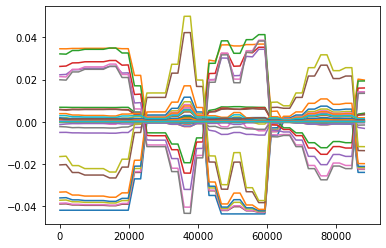

In [15]:
simulation.states.Q_ik.plot(legend=False)